# 乾物(C-H)バンドに絞った EDA
高含水で飽和せず勾配を保つ乾物バンドだけを大きく可視化する。

- **C-H 1715** : sg2 1700-1740 (高MC域r=+0.65, 最有力)
- **C-H 2320** : sg2 2300-2340 (高MC域r=+0.60)
- **C-H 1270** : sg1 1260-1300 (高MC域r=+0.43)

ベイスギ(MC最大298%)を赤★で強調。

In [1]:
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.stats import spearmanr
matplotlib.rcParams['font.family'] = ['Hiragino Sans','AppleGothic','sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 120

tr = pd.read_csv('../data/train_clean.csv', encoding='shift_jis')
META = ['sample number','species number','樹種','含水率']
wn_cols = [c for c in tr.columns if c not in META]
wn = np.array([float(c) for c in wn_cols]); wl = 1e7 / wn
order = np.argsort(wl); nm = wl[order]
X  = tr[wn_cols].values.astype(float)[:, order]
mc = tr['含水率'].values.astype(float); sp = tr['樹種'].values
species = np.unique(sp)
snv = lambda M: (M - M.mean(1, keepdims=True)) / (M.std(1, keepdims=True) + 1e-8)
sg  = lambda M, d: savgol_filter(M, 11, 2, deriv=d, axis=1)
S1, S2 = sg(snv(X),1), sg(snv(X),2)

# 乾物3バンドのみ
DRY = {
  'C-H 1715 (sg2 1700-1740)': (S2, 1700, 1740, 'mean'),
  'C-H 2320 (sg2 2300-2340)': (S2, 2300, 2340, 'mean'),
  'C-H 1270 (sg1 1260-1300)': (S1, 1260, 1300, 'max'),
}
def featv(M,lo,hi,st):
    B=M[:,(nm>=lo)&(nm<=hi)]
    return {'mean':B.mean(1),'max':B.max(1),'min':B.min(1)}[st]
feats = {k: featv(*v) for k,v in DRY.items()}
ced = sp=='ベイスギ'
print('準備OK | 乾物バンド', list(DRY))

準備OK | 乾物バンド ['C-H 1715 (sg2 1700-1740)', 'C-H 2320 (sg2 2300-2340)', 'C-H 1270 (sg1 1260-1300)']


## 1. 各乾物バンドの2次微分スペクトル(MCビン別・ズーム)
MCが上がるほどピークが単調に動けば、その帯域は高MC情報を保持している。

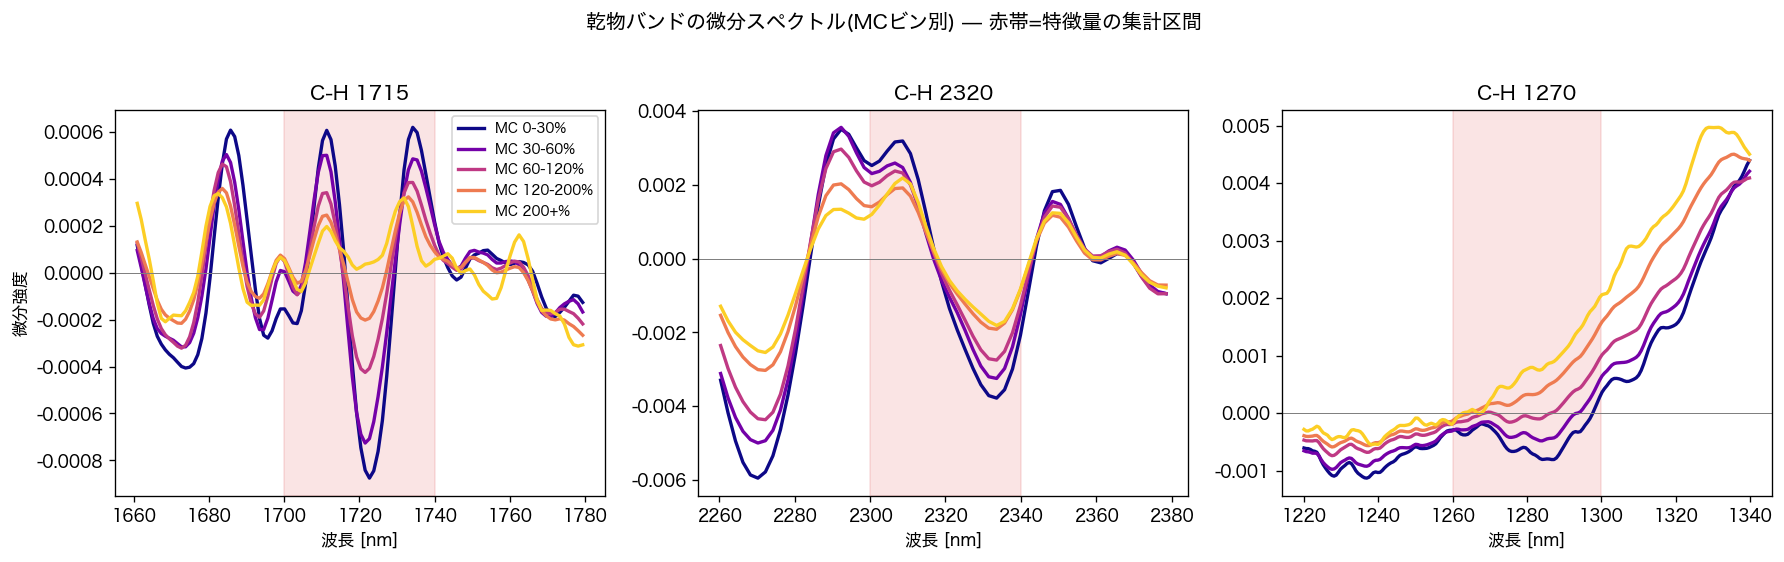

In [2]:
bins   = [0,30,60,120,200,310]; labels=['0-30','30-60','60-120','120-200','200+']
cidx   = np.digitize(mc, bins)-1
cols   = plt.cm.plasma(np.linspace(0,0.9,len(labels)))
zoom   = {'C-H 1715':(1660,1780,S2),'C-H 2320':(2260,2380,S2),'C-H 1270':(1220,1340,S1)}
fig, ax = plt.subplots(1,3, figsize=(15,4.5))
for a,(name,(lo,hi,M)) in zip(ax, zoom.items()):
    for k in range(len(labels)):
        m=(cidx==k); sel=(nm>=lo)&(nm<=hi)
        a.plot(nm[sel], M[m][:,sel].mean(0), color=cols[k], lw=2, label=f'MC {labels[k]}%')
    band=[v[1:3] for kk,v in DRY.items() if name in kk][0]
    a.axvspan(band[0],band[1],color='C3',alpha=.12)
    a.set_title(name); a.set_xlabel('波長 [nm]'); a.axhline(0,color='gray',lw=.6)
ax[0].set_ylabel('微分強度'); ax[0].legend(fontsize=8)
plt.suptitle('乾物バンドの微分スペクトル(MCビン別) — 赤帯=特徴量の集計区間', y=1.03)
plt.tight_layout(); plt.show()

## 2. 乾物特徴量 vs 含水率(大きく)
点をMCで色付け、ベイスギを赤★。高MC(破線120%超)でも傾きが残るかを見る。

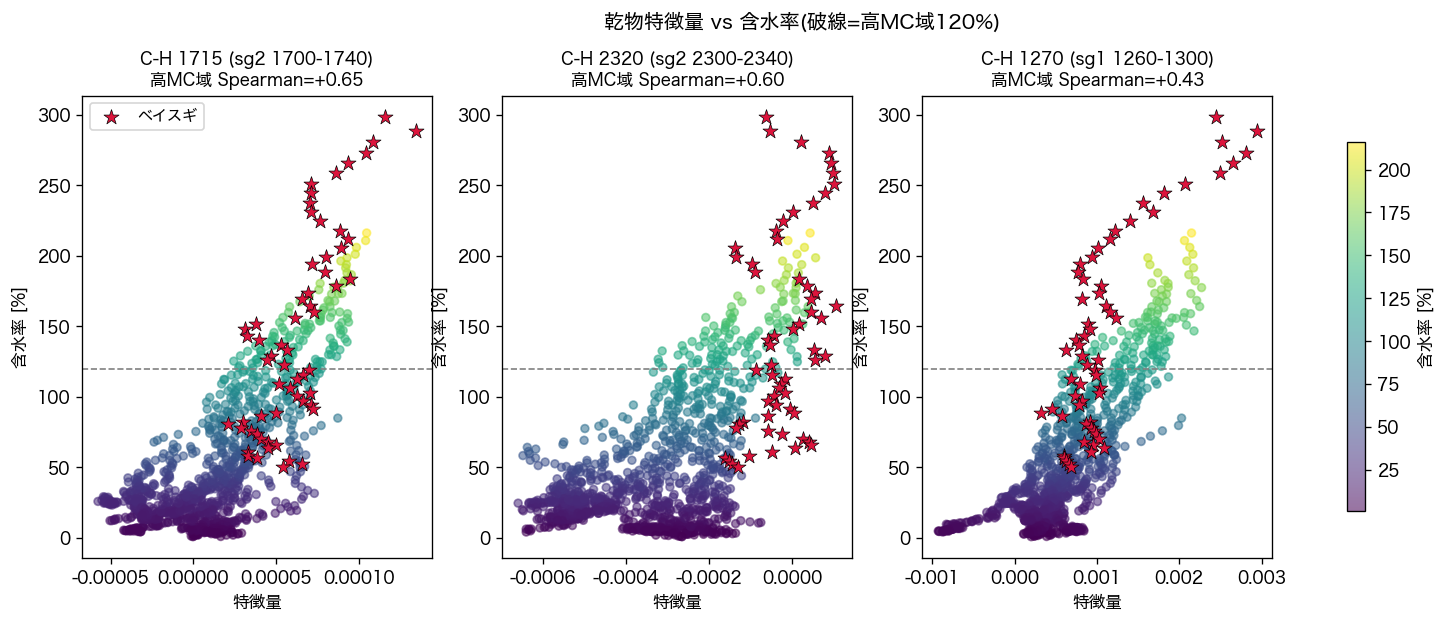

In [3]:
fig, ax = plt.subplots(1,3, figsize=(16,5))
for a,(name,v) in zip(ax, feats.items()):
    s=a.scatter(v[~ced], mc[~ced], s=22, alpha=.55, c=mc[~ced], cmap='viridis')
    a.scatter(v[ced], mc[ced], s=90, marker='*', c='crimson', edgecolor='k',
              linewidth=.4, label='ベイスギ', zorder=3)
    a.axhline(120, color='gray', ls='--', lw=1)
    r_hi = spearmanr(v[mc>120], mc[mc>120]).correlation
    a.set_title(f'{name}\n高MC域 Spearman={r_hi:+.2f}', fontsize=10)
    a.set_xlabel('特徴量'); a.set_ylabel('含水率 [%]')
ax[0].legend(loc='upper left', fontsize=9)
fig.colorbar(s, ax=ax, label='含水率 [%]', shrink=.8)
plt.suptitle('乾物特徴量 vs 含水率(破線=高MC域120%)', y=1.02)
plt.show()

## 3. 最有力 C-H 1715 の樹種別関係
樹種をまたいで同じ傾きに乗るほど、樹種非依存=外挿に使える。ベイスギ(★)が他樹種の延長に乗るか。

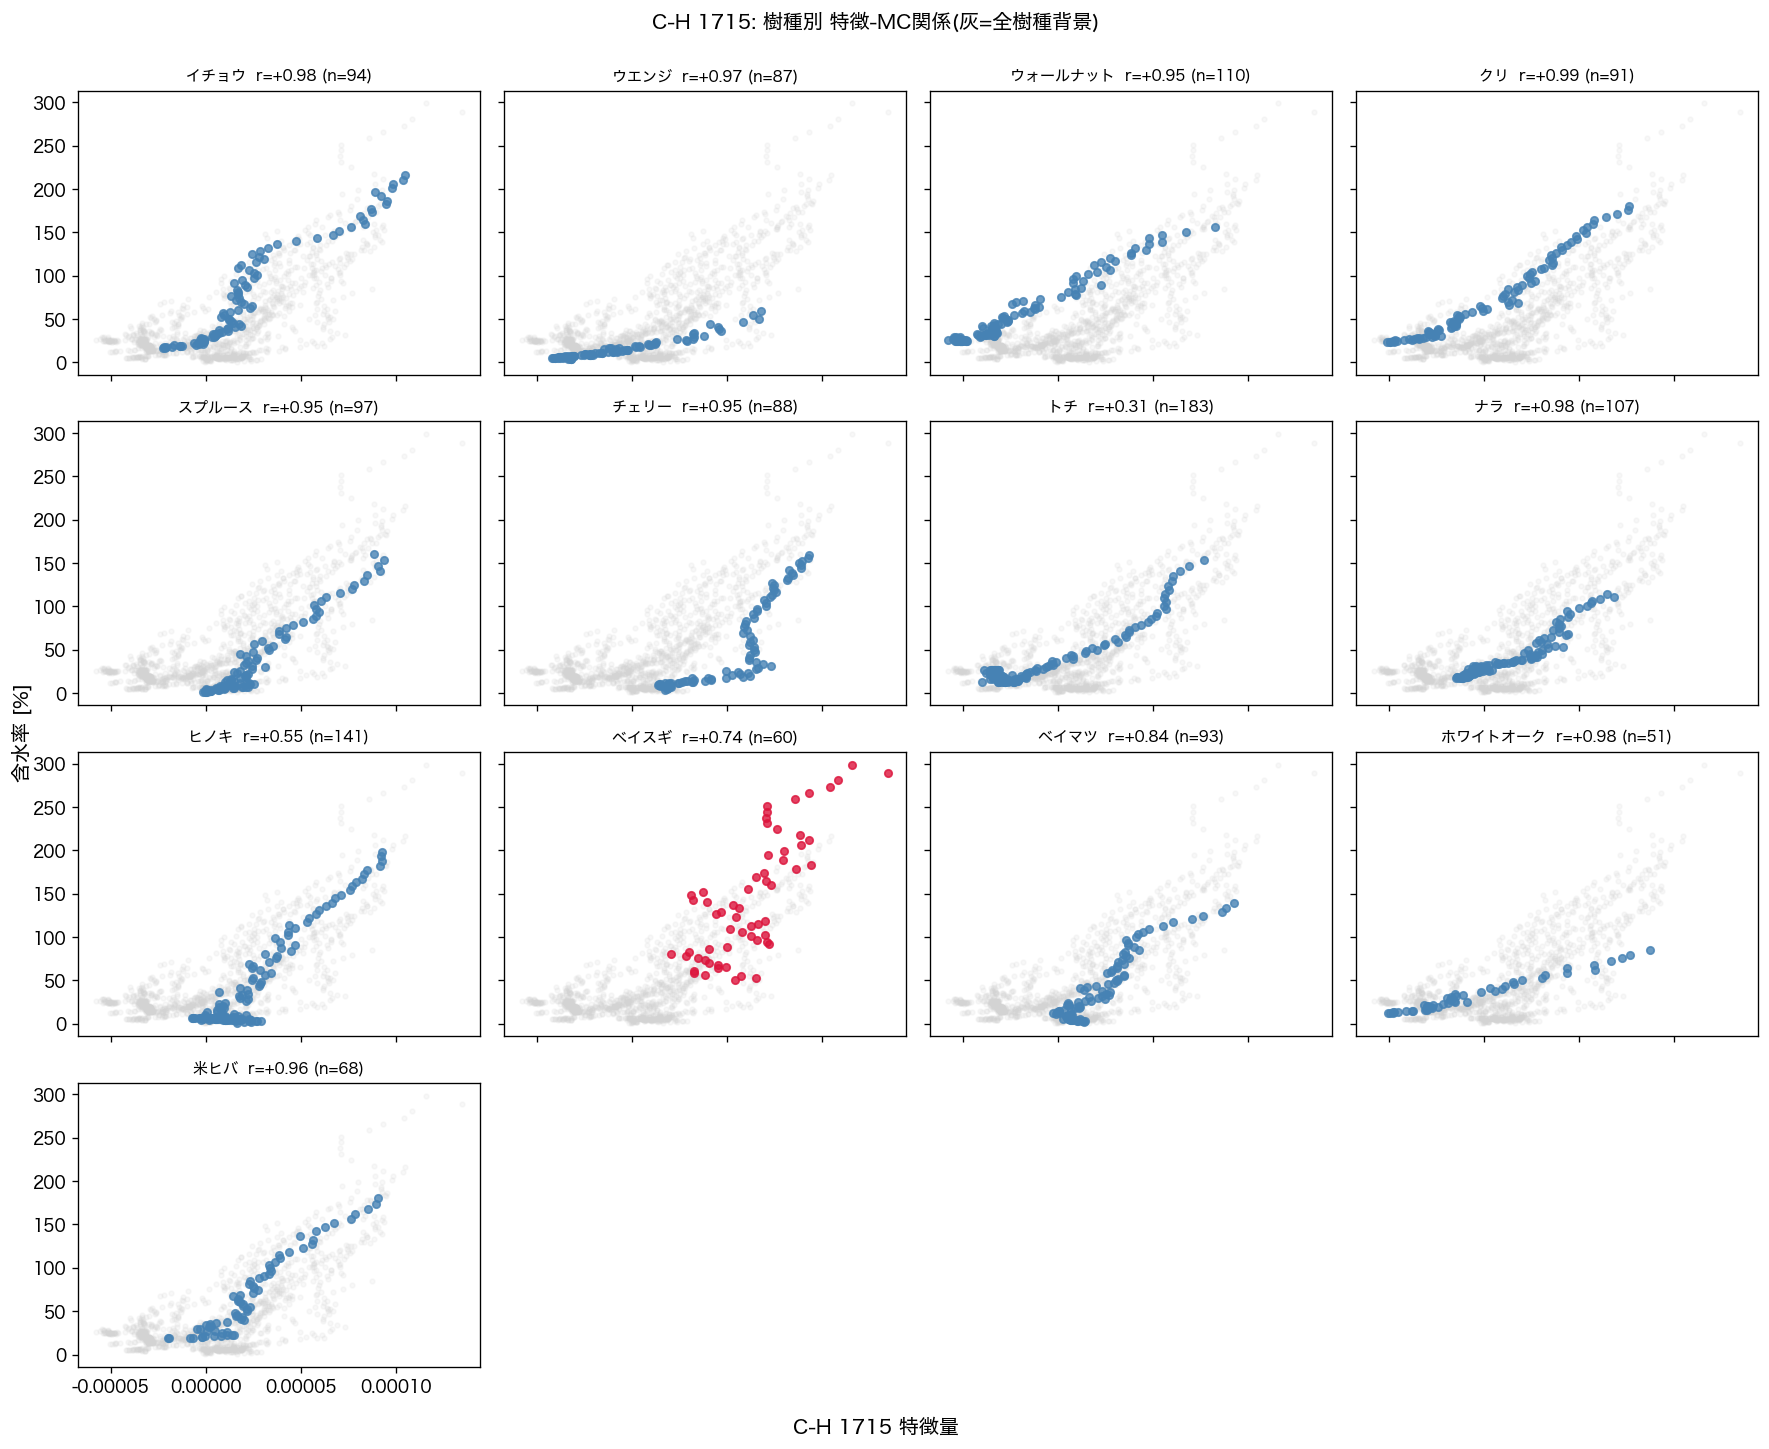

In [4]:
v = feats['C-H 1715 (sg2 1700-1740)']
ncol=4; nrow=int(np.ceil(len(species)/ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(15, 3.0*nrow), sharex=True, sharey=True)
ax=ax.ravel()
for i,s in enumerate(species):
    m=sp==s
    ax[i].scatter(v[~m], mc[~m], s=8, alpha=.15, c='lightgray')   # 他樹種を背景に
    ax[i].scatter(v[m],  mc[m],  s=20, alpha=.8,
                  c=('crimson' if s=='ベイスギ' else 'steelblue'))
    r=spearmanr(v[m],mc[m]).correlation
    ax[i].set_title(f'{s}  r={r:+.2f} (n={m.sum()})', fontsize=9)
for j in range(len(species),len(ax)): ax[j].axis('off')
fig.supxlabel('C-H 1715 特徴量'); fig.supylabel('含水率 [%]')
plt.suptitle('C-H 1715: 樹種別 特徴-MC関係(灰=全樹種背景)', y=1.0)
plt.tight_layout(); plt.show()

## 4. 統計特徴(8統計量 × 乾物バンド)と含水率の相関
強度系(mean/max)だけでなく std/min/amp/slope/area/cr_depth も作り、
含水率との相関を **全体** と **高MC域(>120%)** で比較する(fft_band と同じ統計量セット)。

特徴数 = 48 ( 6 バンド ×8統計量 )  高MC域 n= 146


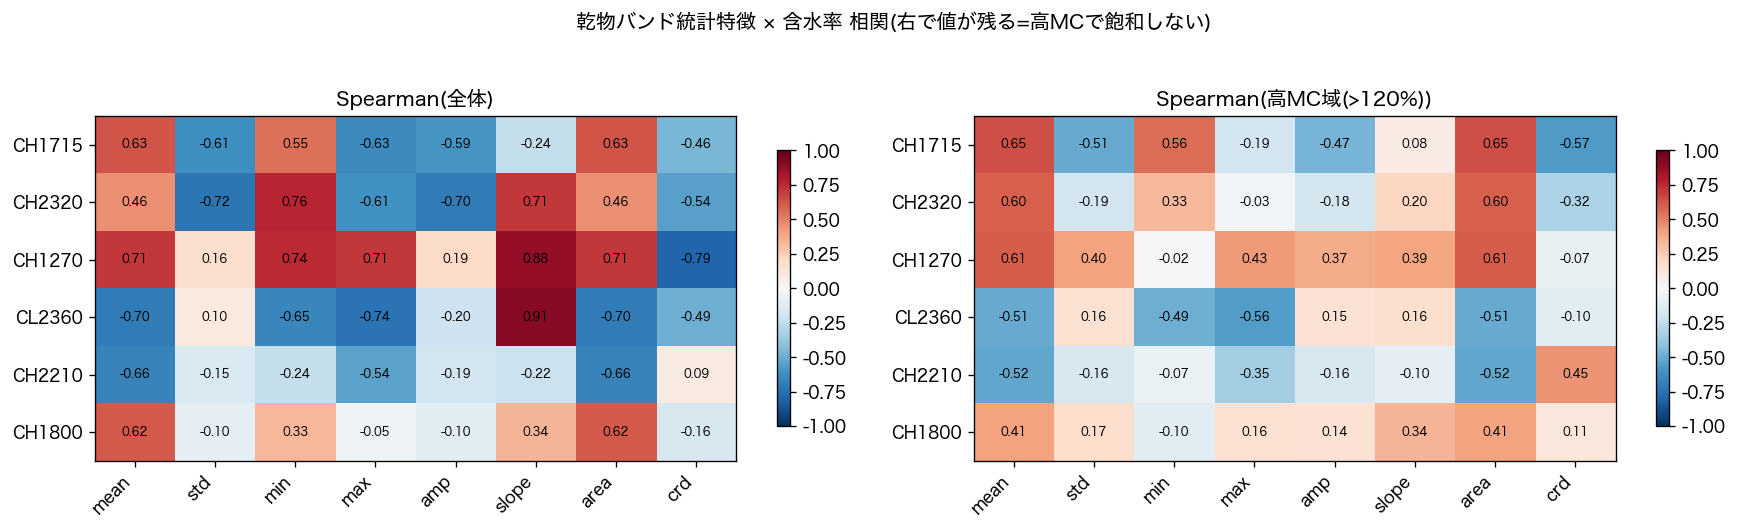

In [5]:
# 乾物バンド(チャネル, 帯域) — fft_band と同様に複数バンド
DRY_BANDS = {
  'CH1715':(S2,1700,1740), 'CH2320':(S2,2300,2340), 'CH1270':(S1,1260,1300),
  'CL2360':(snv(X),2340,2400), 'CH2210':(S2,2200,2240), 'CH1800':(S2,1780,1840),
}
def cr_depth(B):
    n=B.shape[1]; line=np.linspace(B[:,0],B[:,-1],n).T; return (line-B).max(1)
def stats(B,w):
    return {'mean':B.mean(1),'std':B.std(1),'min':B.min(1),'max':B.max(1),
            'amp':B.max(1)-B.min(1),'slope':np.polyfit(w,B.T,1)[0],
            'area':B.sum(1),'crd':cr_depth(B)}
STAT_ORDER=['mean','std','min','max','amp','slope','area','crd']

hi = mc>120
rows_all, rows_hi = {}, {}
for bn,(M,lo,hi_) in DRY_BANDS.items():
    sel=(nm>=lo)&(nm<=hi_); B=M[:,sel]; w=nm[sel]
    sd=stats(B,w)
    rows_all[bn]=[spearmanr(sd[st],mc).correlation        for st in STAT_ORDER]
    rows_hi[bn] =[spearmanr(sd[st][hi],mc[hi]).correlation for st in STAT_ORDER]
C_all=pd.DataFrame(rows_all,index=STAT_ORDER).T
C_hi =pd.DataFrame(rows_hi, index=STAT_ORDER).T
print('特徴数 =', C_all.size, '(', len(DRY_BANDS),'バンド ×8統計量 )  高MC域 n=',hi.sum())

fig, ax = plt.subplots(1,2, figsize=(15,4.2))
for a,(C,t) in zip(ax,[(C_all,'全体'),(C_hi,'高MC域(>120%)')]):
    im=a.imshow(C.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    a.set_xticks(range(len(STAT_ORDER))); a.set_xticklabels(STAT_ORDER, rotation=45, ha='right')
    a.set_yticks(range(len(C))); a.set_yticklabels(C.index)
    for i in range(C.shape[0]):
        for j in range(C.shape[1]):
            a.text(j,i,f'{C.values[i,j]:.2f}',ha='center',va='center',fontsize=7)
    a.set_title(f'Spearman({t})'); fig.colorbar(im,ax=a,shrink=.8)
plt.suptitle('乾物バンド統計特徴 × 含水率 相関(右で値が残る=高MCで飽和しない)', y=1.04)
plt.tight_layout(); plt.show()

,feature,r_all,r_highMC
0,CH1715|mean,0.629,0.648
1,CH1715|area,0.629,0.648
2,CH1270|area,0.708,0.606
3,CH1270|mean,0.708,0.606
4,CH2320|area,0.457,0.598
5,CH2320|mean,0.457,0.598
6,CH1715|crd,-0.458,-0.567
7,CH1715|min,0.554,0.558
8,CL2360|max,-0.737,-0.555
9,CH2210|area,-0.665,-0.518


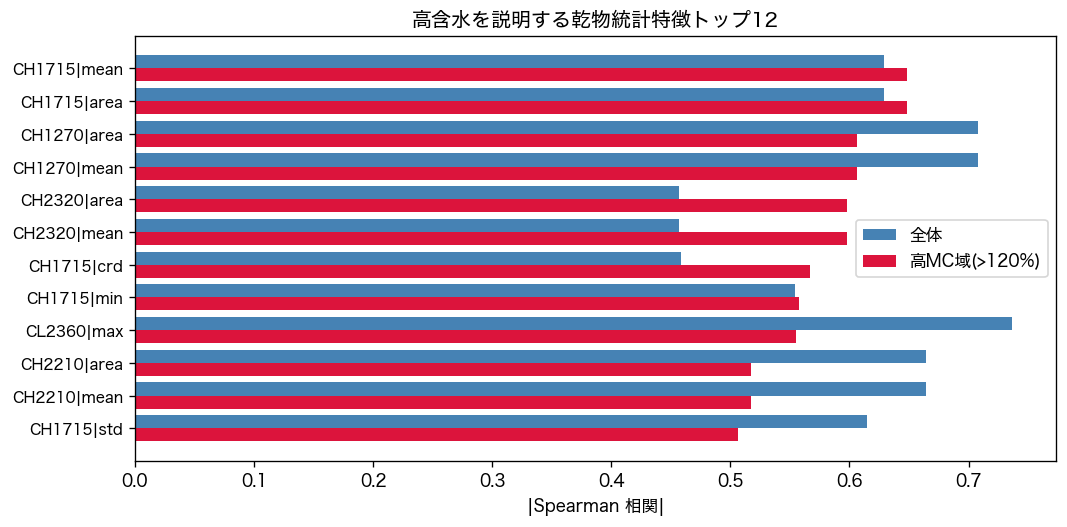

In [6]:
# 高MC域で|相関|が高い統計特徴トップ12(=高含水を説明する候補)
flat = (C_hi.stack().rename('r_highMC').reset_index()
          .rename(columns={'level_0':'band','level_1':'stat'}))
flat['r_all'] = [C_all.loc[b,s] for b,s in zip(flat.band,flat.stat)]
flat['feature'] = flat.band+'|'+flat.stat
top = flat.reindex(flat.r_highMC.abs().sort_values(ascending=False).index).head(12)
display(top[['feature','r_all','r_highMC']].round(3).reset_index(drop=True))

fig,ax=plt.subplots(figsize=(9,4.5)); y=np.arange(len(top))
ax.barh(y-0.2, top.r_all.abs(),     0.4, color='steelblue', label='全体')
ax.barh(y+0.2, top.r_highMC.abs(),  0.4, color='crimson',   label='高MC域(>120%)')
ax.set_yticks(y); ax.set_yticklabels(top.feature,fontsize=9); ax.invert_yaxis()
ax.set_xlabel('|Spearman 相関|'); ax.legend(); ax.set_title('高含水を説明する乾物統計特徴トップ12')
plt.tight_layout(); plt.show()

## 5. 非線形関数への当てはまりやすさ (R²)
相関(線形/単調の強さ)ではなく、**MC = φ(特徴量)** を各関数形で当てはめた R² を比較する。
当てはめる関数形:
- `linear`  : MC = a·f + b
- `quad`    : MC = a·f² + b·f + c (柔軟な非線形ベースライン)
- `exp`     : MC = A·exp(B·f) + C (指数: 外挿で伸びる)
- `log`     : MC = a·ln(f − f₀) + b (対数: 高域で飽和)

R² は **全体** と **高MC域(>120%)** の両方で評価(高域でも高R²=外挿に向く関数形)。

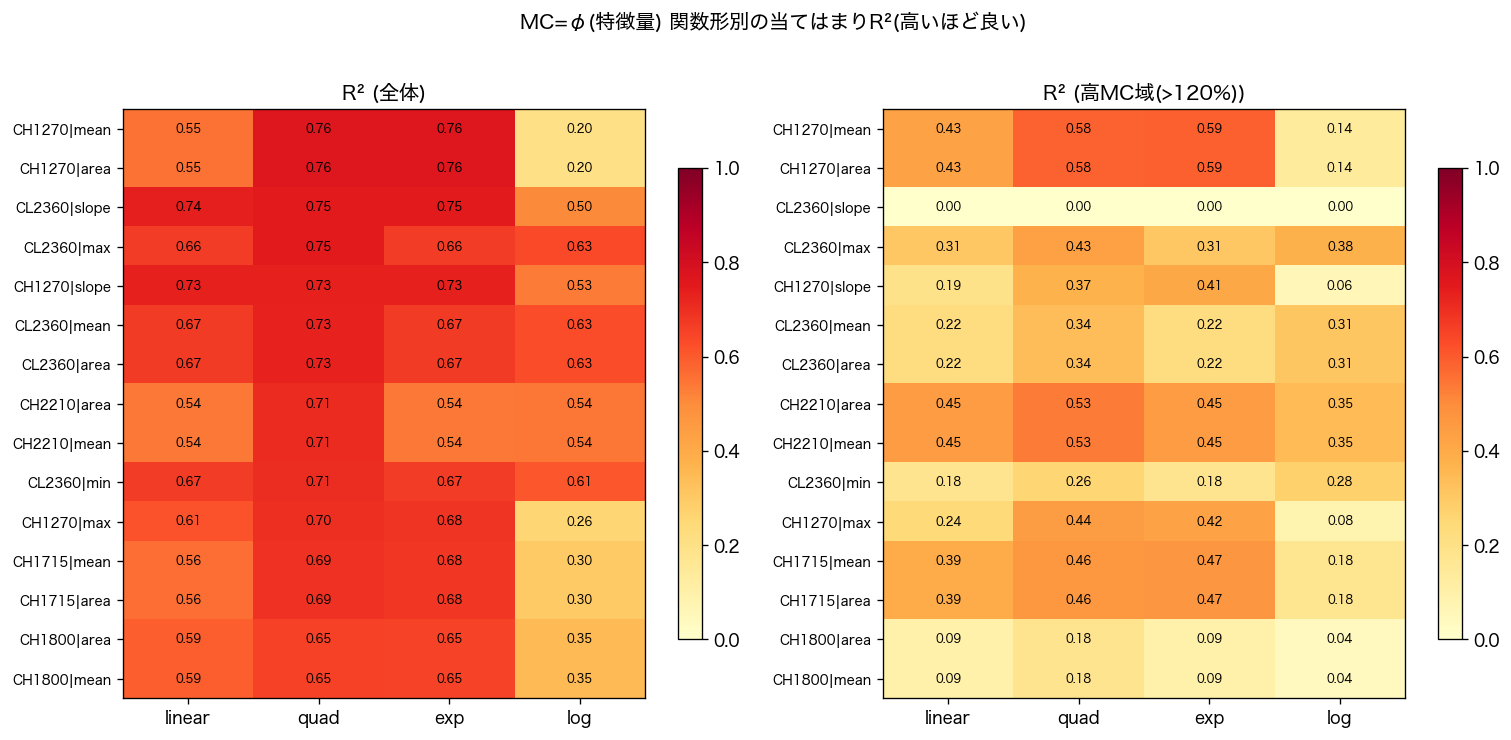

In [7]:
from scipy.optimize import curve_fit
def r2(y, yh):
    ss=((y-y.mean())**2).sum(); return 1-((y-yh)**2).sum()/ss if ss>0 else np.nan
def fit_forms(f, y):
    out={}
    # linear / quad: 解析解
    out['linear']=r2(y, np.polyval(np.polyfit(f,y,1), f))
    out['quad']  =r2(y, np.polyval(np.polyfit(f,y,2), f))
    # exp: MC = A exp(B f)+C
    try:
        p,_=curve_fit(lambda x,A,B,C:A*np.exp(B*x)+C, f, y,
                      p0=[y.std(),1/(f.std()+1e-6),y.min()], maxfev=20000)
        out['exp']=r2(y, p[0]*np.exp(p[1]*f)+p[2])
    except Exception: out['exp']=np.nan
    # log: MC = a ln(f-f0)+b, f0は最小値より少し下
    g=f-f.min()+1e-3*(f.std()+1e-9)
    try:
        p,_=curve_fit(lambda x,a,b:a*np.log(x)+b, g, y, p0=[y.std(),y.mean()], maxfev=20000)
        out['log']=r2(y, p[0]*np.log(g)+p[1])
    except Exception: out['log']=np.nan
    return out

# §4 の48特徴を再構成
feat_mat, feat_names = {}, []
for bn,(M,lo,hi_) in DRY_BANDS.items():
    sel=(nm>=lo)&(nm<=hi_); B=M[:,sel]; w=nm[sel]
    for st,v in stats(B,w).items():
        feat_mat[f'{bn}|{st}']=v
hi = mc>120
FORMS=['linear','quad','exp','log']
rows_all, rows_hi = {}, {}
for name,v in feat_mat.items():
    rows_all[name]=fit_forms(v, mc)
    rows_hi[name] =fit_forms(v[hi], mc[hi])
R_all=pd.DataFrame(rows_all).T[FORMS]
R_hi =pd.DataFrame(rows_hi).T[FORMS]
# 全体R²(quad基準)で上位15特徴に絞って表示
top=R_all['quad'].sort_values(ascending=False).head(15).index
fig,ax=plt.subplots(1,2,figsize=(13,6))
for a,(R,t) in zip(ax,[(R_all,'全体'),(R_hi,'高MC域(>120%)')]):
    D=R.loc[top].clip(0,1)
    im=a.imshow(D.values,cmap='YlOrRd',vmin=0,vmax=1,aspect='auto')
    a.set_xticks(range(len(FORMS)));a.set_xticklabels(FORMS)
    a.set_yticks(range(len(top)));a.set_yticklabels(top,fontsize=8)
    for i in range(D.shape[0]):
        for j in range(D.shape[1]):
            a.text(j,i,f'{D.values[i,j]:.2f}',ha='center',va='center',fontsize=7)
    a.set_title(f'R² ({t})');fig.colorbar(im,ax=a,shrink=.8)
plt.suptitle('MC=φ(特徴量) 関数形別の当てはまりR²(高いほど良い)',y=1.02)
plt.tight_layout();plt.show()

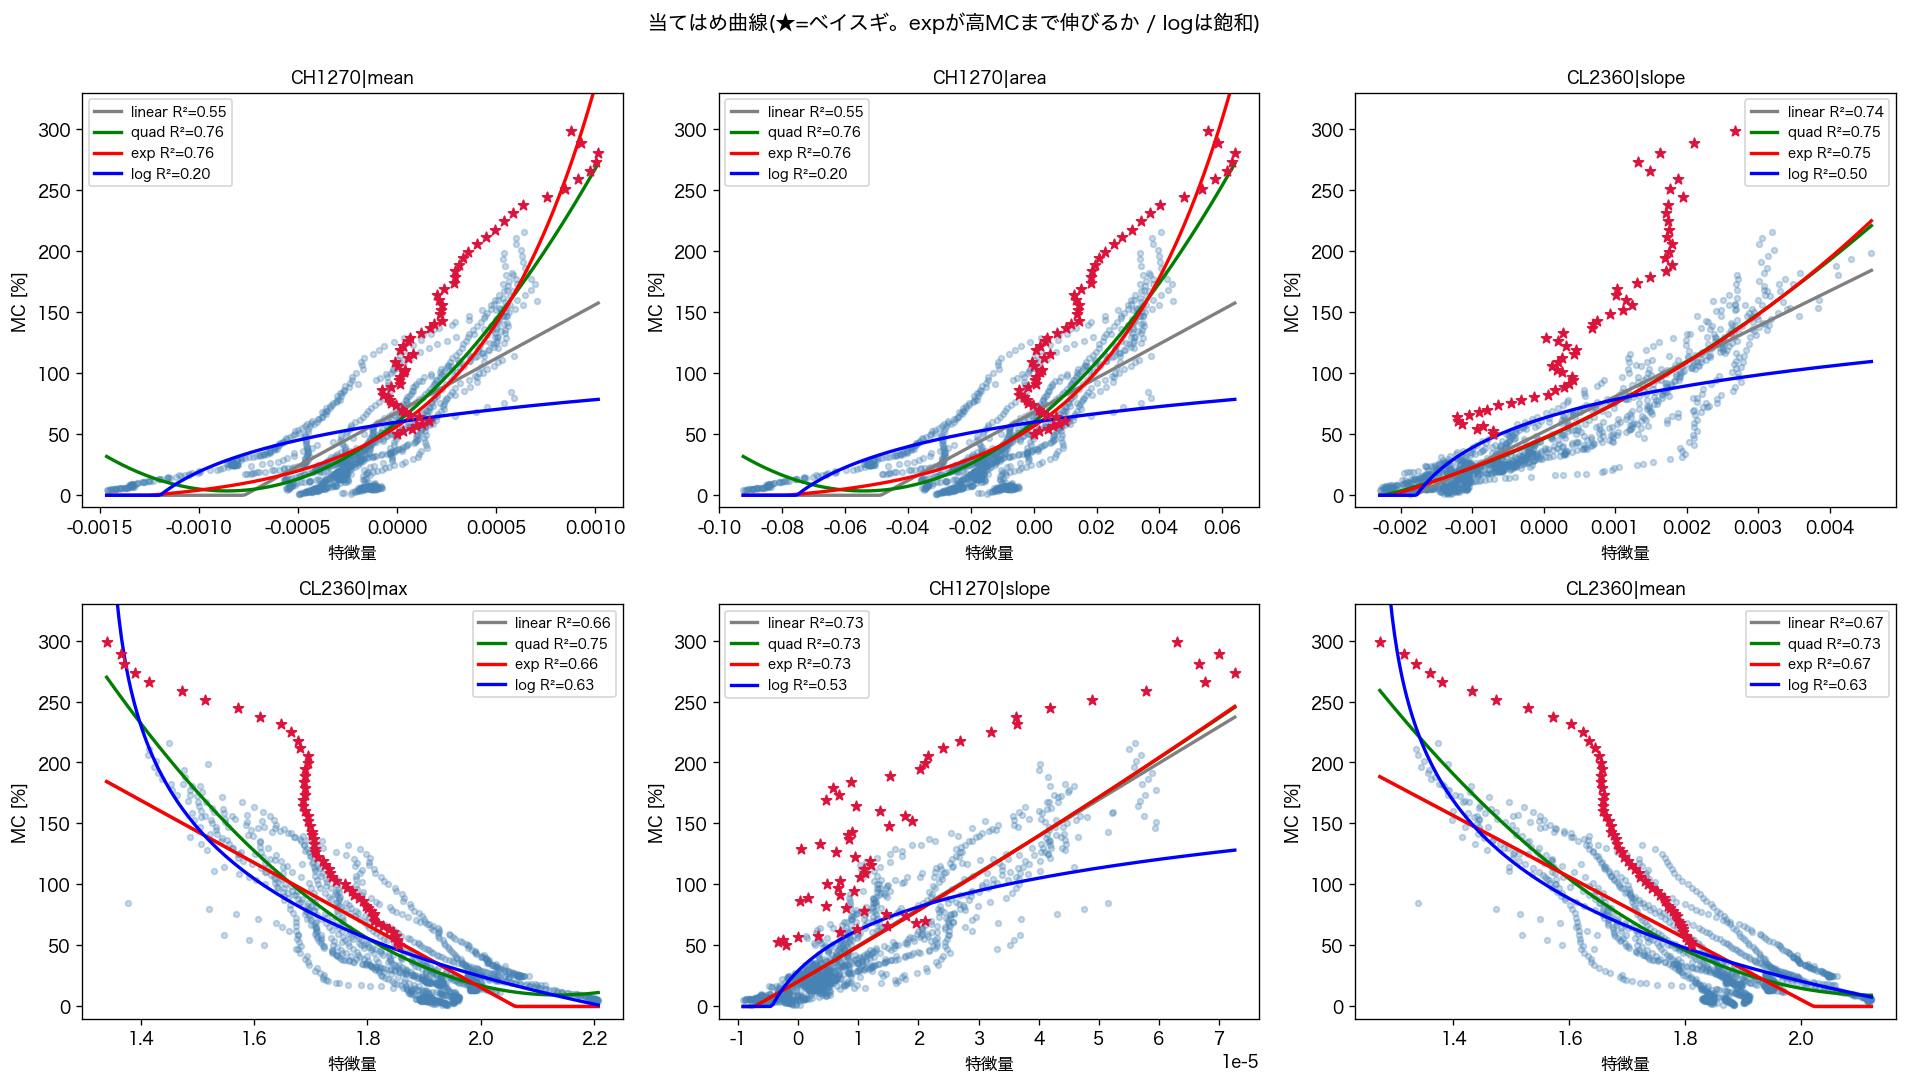

In [8]:
# 当てはめ曲線を重ねて目視確認(高R²の代表6特徴)
def curves(f, y):
    xs=np.linspace(f.min(), f.max(), 200); out={}
    out['linear']=('linear',xs,np.polyval(np.polyfit(f,y,1),xs))
    out['quad']  =('quad',  xs,np.polyval(np.polyfit(f,y,2),xs))
    try:
        p,_=curve_fit(lambda x,A,B,C:A*np.exp(B*x)+C,f,y,
                      p0=[y.std(),1/(f.std()+1e-6),y.min()],maxfev=20000)
        out['exp']=('exp',xs,p[0]*np.exp(p[1]*xs)+p[2])
    except Exception: pass
    g=f-f.min()+1e-3*(f.std()+1e-9); gx=xs-f.min()+1e-3*(f.std()+1e-9)
    try:
        p,_=curve_fit(lambda x,a,b:a*np.log(x)+b,g,y,p0=[y.std(),y.mean()],maxfev=20000)
        out['log']=('log',xs,p[0]*np.log(gx)+p[1])
    except Exception: pass
    return out
ced=sp=='ベイスギ'
sel_feats=list(top[:6])
fig,ax=plt.subplots(2,3,figsize=(16,9)); ax=ax.ravel()
cmap={'linear':'gray','quad':'green','exp':'red','log':'blue'}
for a,name in zip(ax,sel_feats):
    f=feat_mat[name]
    a.scatter(f[~ced],mc[~ced],s=12,alpha=.3,c='steelblue')
    a.scatter(f[ced], mc[ced], s=40,marker='*',c='crimson',zorder=3)
    for form,xs,ys in curves(f,mc).values():
        a.plot(xs,np.clip(ys,0,350),color=cmap[form],lw=2,
               label=f'{form} R²={R_all.loc[name,form]:.2f}')
    a.set_title(name,fontsize=10);a.set_xlabel('特徴量');a.set_ylabel('MC [%]')
    a.legend(fontsize=8);a.set_ylim(-10,330)
plt.suptitle('当てはめ曲線(★=ベイスギ。expが高MCまで伸びるか / logは飽和)',y=1.0)
plt.tight_layout();plt.show()